## Calculating avg pol hist at constant Mach number

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def wavy_field_kolmo(M_A, Bz_true, amplitude_range, g_size, plotting=False):
    """
    ISM toy polarization model with 3D Kolmogorov turbulence parameterized
    by Alfvénic Mach number M_A.

    Turbulence model:
      - Random Gaussian vector field generated in Fourier space
      - Weighted by a Kolmogorov power spectrum: |B_k|^2 ∝ k^(-11/3),
        so amplitude ∝ k^(-11/6)
      - Projected onto the plane perpendicular to k (ensures ∇·B = 0)
      - Normalised so that rms(δB) = M_A (in units where B_mean = √2)
      - Added to the large-scale field; the full field is then re-projected
        to remain divergence-free
    """

    # ------------------------------------------------------------------
    # PARAMETERS
    # ------------------------------------------------------------------
    I0 = 1.0
    frequency = 1.0
    amplitude = np.linspace(amplitude_range[0], amplitude_range[1], g_size)
    Bx0, By0 = 1.0, 1.0

    # ------------------------------------------------------------------
    # GRID
    # ------------------------------------------------------------------
    x = np.linspace(-np.pi, np.pi, g_size)
    y = np.linspace(-np.pi, np.pi, g_size)
    z = np.linspace(-np.pi, np.pi, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    Bx = np.zeros_like(X)
    By = np.zeros_like(Y)
    Bz = np.zeros_like(Z)

    # ------------------------------------------------------------------
    # LARGE-SCALE POS FIELD  (wavy structure along x)
    # ------------------------------------------------------------------

    for iz in range(g_size):
        theta0 = amplitude[iz] * np.cos(frequency * X[:, :, iz])
        Bx[:, :, iz] = Bx0 * np.cos(theta0)
        By[:, :, iz] = By0 * np.sin(theta0)
        Bz[:, :, iz] = Bz_true

    # ------------------------------------------------------------------
    # 3D KOLMOGOROV TURBULENCE
    # ------------------------------------------------------------------
    kx = np.fft.fftfreq(g_size, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(g_size, d=dy) * 2 * np.pi
    kz = np.fft.fftfreq(g_size, d=dz) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="xy")

    k2 = KX**2 + KY**2 + KZ**2
    k  = np.sqrt(k2)

    # --- random complex Gaussian vector field (unit variance per mode) ---
    rng = np.random.default_rng()

    def rand_complex(shape):
        return (rng.standard_normal(shape) + 1j * rng.standard_normal(shape)) / np.sqrt(2)

    Fx = rand_complex(X.shape)
    Fy = rand_complex(X.shape)
    Fz = rand_complex(X.shape)

    # --- Kolmogorov amplitude weighting: |B_k| ∝ k^(-11/6) ---
    # Power spectrum E(k) ∝ k^(-11/3) in 3D  →  amplitude ∝ k^(-11/6)
    # Zero-mode is left at zero (no mean turbulent field).
    with np.errstate(divide="ignore", invalid="ignore"):
        kolmogorov_weight = np.where(k > 0, k ** (-11.0 / 6.0), 0.0)

    Fx *= kolmogorov_weight
    Fy *= kolmogorov_weight
    Fz *= kolmogorov_weight

    # --- Enforce Hermitian symmetry so IFFT is real ---
    # np.fft.ifftn handles this automatically as long as we don't break it;
    # taking .real after ifftn is sufficient for our purposes.

    # --- Project out compressive (longitudinal) component: F → F_perp ---
    # This guarantees ∇·δB = 0 in the continuous sense.
    k2_safe = np.where(k2 > 0, k2, 1.0)   # avoid divide-by-zero at k=0

    k_dot_F = KX * Fx + KY * Fy + KZ * Fz

    Fx -= KX * k_dot_F / k2_safe
    Fy -= KY * k_dot_F / k2_safe
    Fz -= KZ * k_dot_F / k2_safe

    # --- Back to real space ---
    dBx = np.fft.ifftn(Fx).real
    dBy = np.fft.ifftn(Fy).real
    dBz = np.fft.ifftn(Fz).real

    # --- Normalise so that rms(|δB|) = M_A ---
    rms = np.sqrt(np.mean(dBx**2 + dBy**2 + dBz**2))
    if rms > 0:
        dBx *= M_A / rms
        dBy *= M_A / rms
        dBz *= M_A / rms

    # --- Add turbulence to large-scale field ---
    Bx += dBx
    By += dBy
    Bz += dBz

    # ------------------------------------------------------------------
    # ENFORCE DIVERGENCE-FREE CONDITION ON FULL FIELD
    # Project out the longitudinal part of the total field in Fourier space.
    # ------------------------------------------------------------------
    Bx_k = np.fft.fftn(Bx)
    By_k = np.fft.fftn(By)
    Bz_k = np.fft.fftn(Bz)

    k_dot_B = KX * Bx_k + KY * By_k + KZ * Bz_k

    mask = k2 > 0
    Bx_k[mask] -= KX[mask] * k_dot_B[mask] / k2[mask]
    By_k[mask] -= KY[mask] * k_dot_B[mask] / k2[mask]
    Bz_k[mask] -= KZ[mask] * k_dot_B[mask] / k2[mask]

    Bx = np.fft.ifftn(Bx_k).real
    By = np.fft.ifftn(By_k).real
    Bz = np.fft.ifftn(Bz_k).real

    # ------------------------------------------------------------------
    # OPTIONAL FIELD PLOTTING
    # ------------------------------------------------------------------
    if plotting:
        fig, ax = plt.subplots(1, g_size, figsize=(18, 2))
        for iz in range(g_size):
            ax[iz].quiver(
                X[:, :, iz], Y[:, :, iz],
                Bx[:, :, iz], By[:, :, iz],
                pivot="middle",
                scale=2,
                scale_units="xy",
                headlength=0,
                headaxislength=0,
            )
            ax[iz].set_title(f"z={iz}")
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------
    # STOKES PARAMETERS FROM FIELD
    # ------------------------------------------------------------------
    Bperp2 = Bx**2 + By**2
    Btot2  = Bperp2 + Bz**2 + 1e-12

    cos2g = Bperp2 / Btot2
    q = (By**2 - Bx**2) / Btot2
    u = (2 * Bx * By)  / Btot2

    Q3 = I0 * q
    U3 = I0 * u

    # ------------------------------------------------------------------
    # LOS INTEGRATION  (axis=2 is the z / LOS axis)
    # ------------------------------------------------------------------
    Q_obs = Q3.sum(axis=2)
    U_obs = U3.sum(axis=2)
    I_obs = I0 * g_size

    P_obs      = np.sqrt(Q_obs**2 + U_obs**2) / I_obs
    phi_obs    = 0.5 * np.arctan2(U_obs, Q_obs)
    cos2g_LOS  = cos2g.mean(axis=2)

    return P_obs, phi_obs, cos2g_LOS

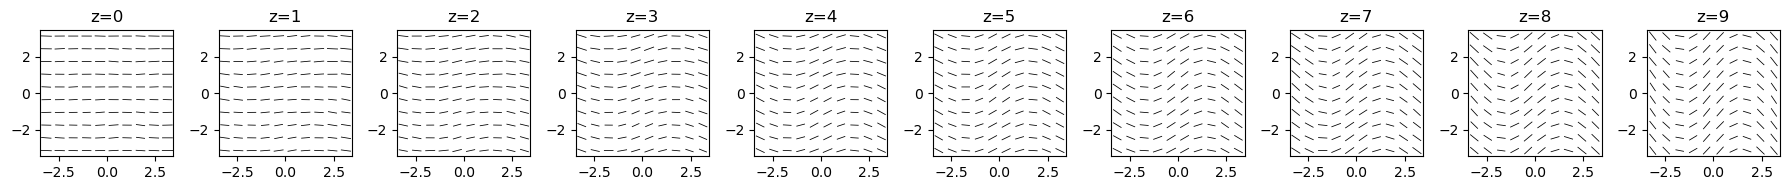

In [23]:
P, PHI, COS = wavy_field_kolmo(M_A=0.1, Bz_true=0, amplitude_range=[0,1], g_size=10, plotting=True)

### parameters

In [25]:
gsize = 64
nbins = 30
nruns = 50

### Sub-Alfvenic Regime

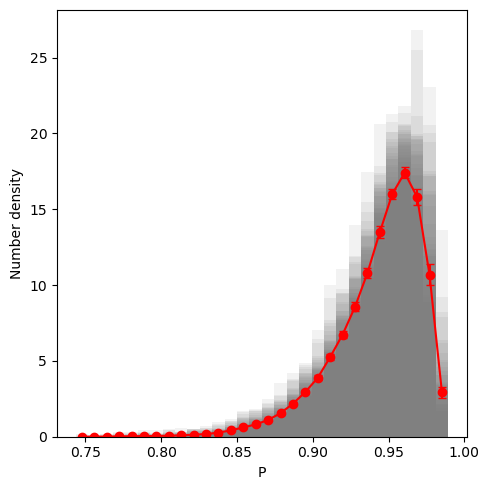

In [30]:
plt.figure(figsize=(5,5))
all_hists = []

P0, PHI, COS = wavy_field_kolmo(M_A=0.25, Bz_true=0, amplitude_range=[1,1], g_size=gsize, plotting=False)
bin_edges = np.histogram_bin_edges(P0.flatten(), bins=nbins)

for i in range(nruns):
    P, PHI, COS = wavy_field_kolmo(M_A=0.25, Bz_true=0, amplitude_range=[1,1], g_size=gsize, plotting=False)
    plt.hist(P.flatten(), bins=bin_edges, alpha=0.1, density=True, color='gray')
    hist, _ = np.histogram(P.flatten(), bins=bin_edges, density=True)
    all_hists.append(hist)

all_hists = np.array(all_hists)

mean_hist = np.mean(all_hists, axis=0)
std_hist  = np.std(all_hists, axis=0)
sem_hist  = std_hist / np.sqrt(nruns)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.errorbar(bin_centers, mean_hist, yerr=sem_hist, fmt='o-', capsize=3, color = 'red')

plt.xlabel("P")
plt.ylabel("Number density")
plt.tight_layout()
plt.show()

### Trans-Alfvenic Regime

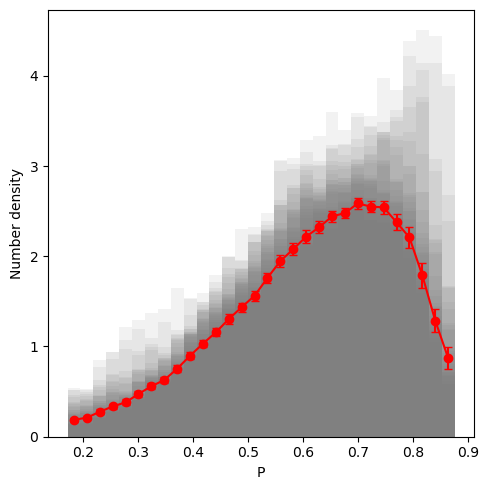

In [31]:
plt.figure(figsize=(5,5))
all_hists = []

P0, PHI, COS = wavy_field_kolmo(M_A=0.75, Bz_true=0, amplitude_range=[1,1], g_size=gsize, plotting=False)
bin_edges = np.histogram_bin_edges(P0.flatten(), bins=nbins)

for i in range(nruns):
    P, PHI, COS = wavy_field_kolmo(M_A=0.75, Bz_true=0, amplitude_range=[1,1], g_size=gsize, plotting=False)
    plt.hist(P.flatten(), bins=bin_edges, alpha=0.1, density=True, color='gray')
    hist, _ = np.histogram(P.flatten(), bins=bin_edges, density=True)
    all_hists.append(hist)

all_hists = np.array(all_hists)

mean_hist = np.mean(all_hists, axis=0)
std_hist  = np.std(all_hists, axis=0)
sem_hist  = std_hist / np.sqrt(nruns)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.errorbar(bin_centers, mean_hist, yerr=sem_hist, fmt='o-', capsize=3, color = 'red')

plt.xlabel("P")
plt.ylabel("Number density")
plt.tight_layout()
plt.show()

### Super-Alfvenic Regime

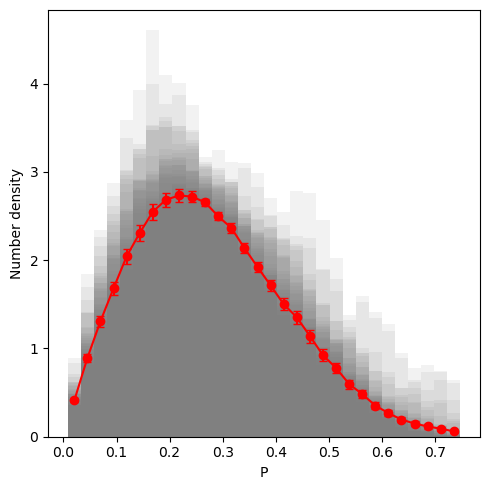

In [32]:
plt.figure(figsize=(5,5))
all_hists = []

P0, PHI, COS = wavy_field_kolmo(M_A=2, Bz_true=0, amplitude_range=[1,1], g_size=gsize, plotting=False)
bin_edges = np.histogram_bin_edges(P0.flatten(), bins=nbins)

for i in range(nruns):
    P, PHI, COS = wavy_field_kolmo(M_A=2, Bz_true=0, amplitude_range=[1,1], g_size=gsize, plotting=False)
    plt.hist(P.flatten(), bins=bin_edges, alpha=0.1, density=True, color='gray')
    hist, _ = np.histogram(P.flatten(), bins=bin_edges, density=True)
    all_hists.append(hist)

all_hists = np.array(all_hists)

mean_hist = np.mean(all_hists, axis=0)
std_hist  = np.std(all_hists, axis=0)
sem_hist  = std_hist / np.sqrt(nruns)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.errorbar(bin_centers, mean_hist, yerr=sem_hist, fmt='o-', capsize=3, color = 'red')

plt.xlabel("P")
plt.ylabel("Number density")
plt.tight_layout()
plt.show()

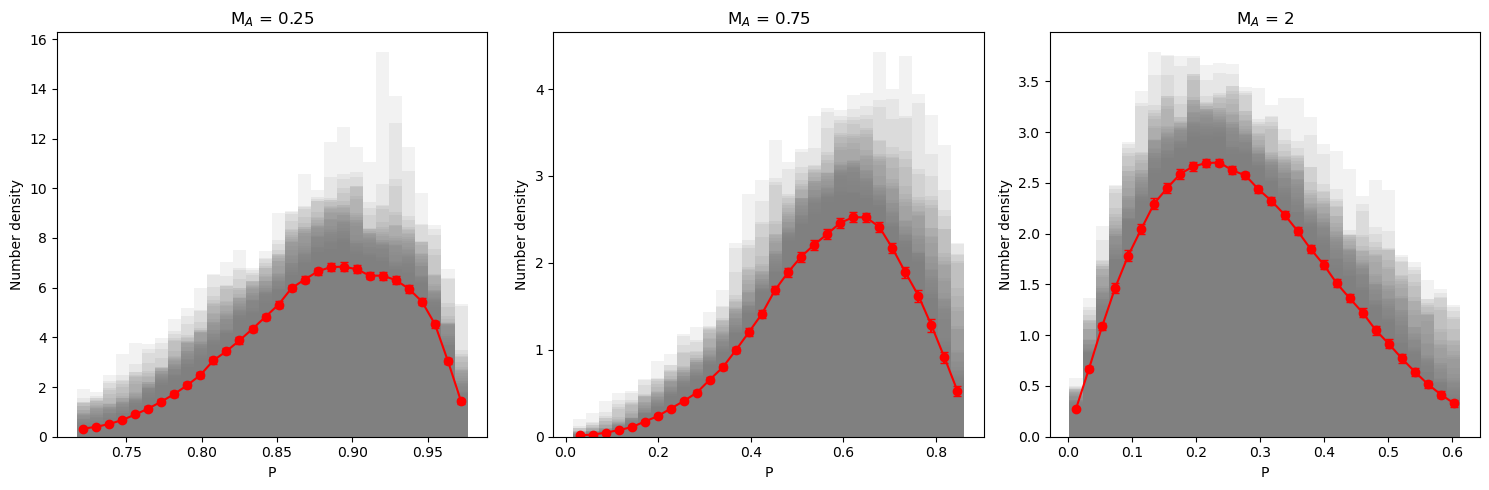

In [36]:
gsize = 64
nbins = 30
nruns = 100

mach_numbers = [0.25, 0.75, 2]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for j, Mval in enumerate(mach_numbers):

    ax           = axes[j]
    all_hists    = []
    P0, PHI, COS = wavy_field_kolmo(M_A=Mval, Bz_true=0, amplitude_range=[0,1], g_size=gsize, plotting=False)
    bin_edges    = np.histogram_bin_edges(P0.flatten(), bins=nbins)

    for i in range(nruns):
        P, PHI, COS = wavy_field_kolmo(M_A=Mval, Bz_true=0, amplitude_range=[0,1], g_size=gsize, plotting=False)
        hist, _ = np.histogram(P.flatten(), bins=bin_edges, density=True)
        all_hists.append(hist)

        ax.hist(P.flatten(), bins=bin_edges, alpha=0.1, density=True, color='gray')

    all_hists = np.array(all_hists)
    mean_hist = np.mean(all_hists, axis=0)
    std_hist  = np.std(all_hists, axis=0)
    sem_hist  = std_hist / np.sqrt(nruns)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    ax.errorbar(bin_centers, mean_hist, yerr=sem_hist, fmt='o-', capsize=3, color='red')
    ax.set_xlabel("P")
    ax.set_ylabel("Number density")
    ax.set_title(f"M$_A$ = {Mval}")

plt.tight_layout()
plt.show()